# Module 1.6 — 1D Linear Advection

**Why start here?**
The linear advection equation is the simplest non-trivial PDE. It has an exact solution so you can measure your numerical error precisely. It exposes every major issue in CFD — stability, accuracy, diffusion error, dispersion error — in a setting simple enough to understand them completely before moving to Navier-Stokes.

**The equation:**
$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$

A scalar quantity $u$ (temperature, dye concentration, or a wave) transported at constant speed $c$ without deforming. The exact solution is pure translation: $u(x,t) = u_0(x - ct)$.

**Roadmap:**
1. Physical intuition — what the equation actually describes
2. Discretisation — the four main schemes
3. The CFL condition — the most important stability criterion in CFD
4. Numerical diffusion and dispersion — why your wave smears or wiggles
5. Modified equation analysis — what equation the scheme actually solves
6. Implementation and comparison of all four schemes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Physical Intuition — The Conveyor Belt

### The analogy

Imagine a conveyor belt moving at constant speed $c$ to the right. You place a dye blob on it. The blob moves to the right at speed $c$. It does not spread, shrink, or change shape — it is simply translated.

That is linear advection. The blob's shape is $u(x, 0) = u_0(x)$ at $t=0$. At time $t$, it is at $u(x, t) = u_0(x - ct)$.

### Why this is the hardest equation to solve numerically

The exact solution is a rigid translation. The numerical solution should be exactly the same. But:
- **Upwind scheme**: smooths the blob over time (artificial diffusion)
- **Central scheme**: adds oscillations that weren't there (artificial dispersion)
- **Lax-Friedrichs**: very diffusive — the blob melts away
- **Lax-Wendroff**: second-order accurate but wiggles behind sharp features

None of them is perfect. This tension — diffusion vs. dispersion — is the central design trade-off in CFD numerics.

## 2. The Schemes — Four Approaches to Discretising $c \partial u/\partial x$

All use forward Euler time stepping: $u^{n+1}_i = u^n_i - \Delta t / \Delta x \cdot F_i$

The difference is in how the flux $F_i = c \cdot (\text{face value})$ is computed:

**FTBS — Forward Time, Backward Space (upwind for $c>0$):**
$$u^{n+1}_i = u^n_i - \nu(u^n_i - u^n_{i-1})$$
where $\nu = c\Delta t / \Delta x$ is the **CFL number**. Uses the upstream cell — stable but diffusive.

**FTCS — Forward Time, Central Space:**
$$u^{n+1}_i = u^n_i - \frac{\nu}{2}(u^n_{i+1} - u^n_{i-1})$$
Second-order in space but **unconditionally unstable**. Never use it for pure advection.

**Lax-Friedrichs:**
$$u^{n+1}_i = \frac{u^n_{i+1}+u^n_{i-1}}{2} - \frac{\nu}{2}(u^n_{i+1} - u^n_{i-1})$$
Stable for $|\nu| \leq 1$ but replaces $u^n_i$ with the average of neighbours — very diffusive.

**Lax-Wendroff:**
$$u^{n+1}_i = u^n_i - \frac{\nu}{2}(u^n_{i+1}-u^n_{i-1}) + \frac{\nu^2}{2}(u^n_{i+1}-2u^n_i+u^n_{i-1})$$
Second-order in both space and time. Stable for $|\nu| \leq 1$. Dispersive — oscillates near discontinuities.

## 3. The CFL Condition — Why It Is the Most Important Number in CFD

### Physical interpretation

The CFL number is:
$$\nu = \frac{c \Delta t}{\Delta x} = \frac{\text{distance wave travels in one time step}}{\text{grid spacing}}$$

**If $\nu > 1$:** the wave travels more than one cell per time step. The stencil $(u_i, u_{i-1})$ does not contain the information needed to correctly propagate the wave — the wave has "jumped over" the stencil. Result: the scheme becomes unstable and the solution blows up exponentially.

**If $\nu \leq 1$:** the wave moves at most one cell per step. The stencil contains all the information needed.

**If $\nu = 1$:** For the upwind scheme, the solution is **exact** — the wave translates by exactly one cell, matching the exact shift $u_0(x - c\Delta t)$.

### The CFL condition for common schemes

| Scheme | Stability condition |
|--------|--------------------|
| Upwind (FTBS) | $0 \leq \nu \leq 1$ |
| FTCS | **Unconditionally unstable** (any $\nu$) |
| Lax-Friedrichs | $|\nu| \leq 1$ |
| Lax-Wendroff | $|\nu| \leq 1$ |

### In 2D: the combined CFL condition

$$\nu_{2D} = \left(\frac{|u|}{\Delta x} + \frac{|v|}{\Delta y}\right)\Delta t \leq 1$$

This will appear every time you set the time step in Modules 2–4.

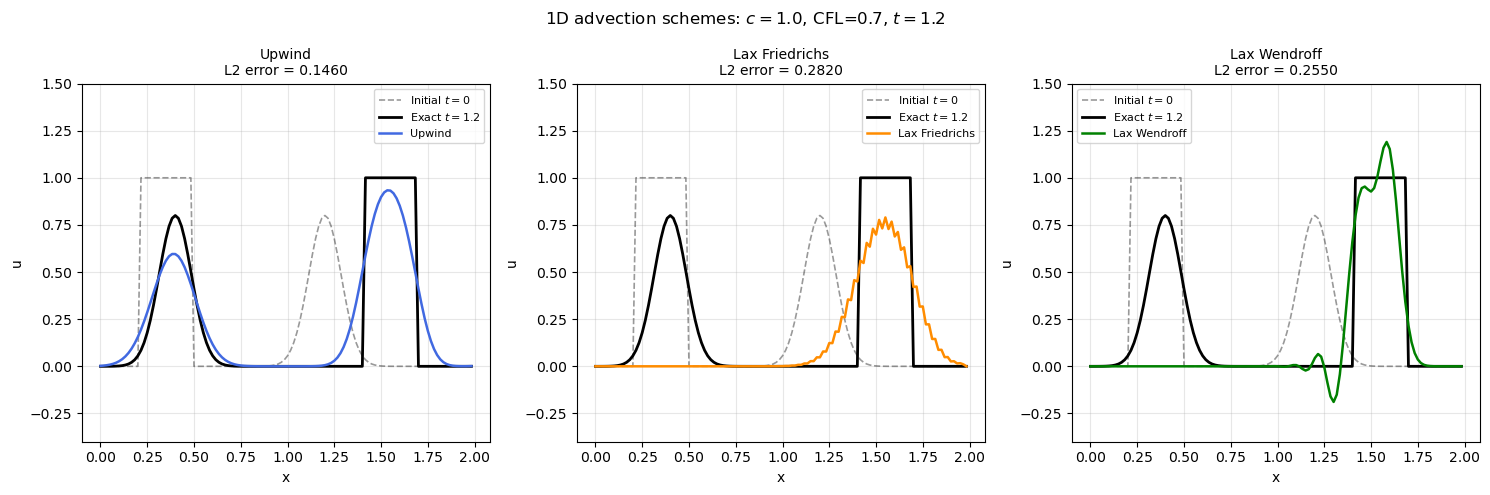

Observations:
  Upwind:        diffusive — step has rounded edges, Gaussian is smeared
  Lax-Friedrichs: very diffusive — even worse than upwind (replaces uᵢ with neighbour average)
  Lax-Wendroff:  dispersive — wiggles behind the step, but Gaussian is sharper


In [2]:
# ── Complete solver with all four schemes ────────────────────────────────────

def advect_1d(u0, c, dx, dt, nt, scheme='upwind'):
    """1D linear advection with periodic BCs."""
    u   = u0.copy()
    nu  = c * dt / dx   # CFL number

    for _ in range(nt):
        un = u.copy()   # must save old values before update

        if scheme == 'upwind':
            # FTBS: backward difference (upwind for c>0)
            u[1:]  = un[1:]  - nu * (un[1:]  - un[:-1])
            u[0]   = un[0]   - nu * (un[0]   - un[-1])   # periodic BC

        elif scheme == 'ftcs':
            # FTCS: central space — UNSTABLE, shown for illustration only
            u[1:-1] = un[1:-1] - nu/2 * (un[2:] - un[:-2])
            u[0]    = un[0]    - nu/2 * (un[1]  - un[-1])
            u[-1]   = un[-1]   - nu/2 * (un[0]  - un[-2])

        elif scheme == 'lax_friedrichs':
            # Stable but very diffusive: averages neighbours first
            u[1:-1] = 0.5*(un[2:]+un[:-2]) - nu/2*(un[2:]-un[:-2])
            u[0]    = 0.5*(un[1] +un[-1] ) - nu/2*(un[1] -un[-1] )
            u[-1]   = u[0]

        elif scheme == 'lax_wendroff':
            # Second-order in space and time, dispersive near shocks
            u[1:-1] = (un[1:-1]
                       - nu/2   * (un[2:]  - un[:-2])
                       + nu**2/2 * (un[2:]  - 2*un[1:-1] + un[:-2]))
            u[0]  = (un[0]
                     - nu/2    * (un[1]  - un[-1])
                     + nu**2/2  * (un[1]  - 2*un[0]  + un[-1]))
            u[-1] = u[0]
    return u

# ── Setup ────────────────────────────────────────────────────────────────────
N   = 120
L   = 2.0
dx  = L / N
x   = np.linspace(0, L, N, endpoint=False)
c   = 1.0
cfl = 0.7                 # CFL number
dt  = cfl * dx / c
T   = 1.2                 # simulate until t=1.2
nt  = int(T / dt)

# ── Initial condition: mixed test — step (discontinuity) + Gaussian (smooth) ─
u0 = np.zeros(N)
u0[(x > 0.2) & (x < 0.5)] = 1.0                        # step — hard test
u0 += 0.8 * np.exp(-((x - 1.2)**2) / 0.015)            # Gaussian — smooth test

# ── Exact solution: shift by c*T (modulo L for periodic domain) ──────────────
x_shifted  = (x - c*T) % L
u_exact    = np.zeros(N)
u_exact[(x_shifted > 0.2) & (x_shifted < 0.5)] = 1.0
u_exact   += 0.8 * np.exp(-((x_shifted - 1.2)**2) / 0.015)

schemes = ['upwind', 'lax_friedrichs', 'lax_wendroff']
colors  = ['royalblue', 'darkorange', 'green']

results = {s: advect_1d(u0, c, dx, dt, nt, s) for s in schemes}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, scheme, color in zip(axes, schemes, colors):
    u_num = results[scheme]
    l2 = np.sqrt(np.mean((u_num - u_exact)**2))
    ax.plot(x, u0,      'k--', lw=1.2, alpha=0.4, label='Initial $t=0$')
    ax.plot(x, u_exact, 'k-',  lw=2,              label='Exact $t=1.2$')
    ax.plot(x, u_num,   '-',   lw=1.8, color=color, label=f'{scheme.replace("_"," ").title()}')
    ax.set_title(f'{scheme.replace("_"," ").title()}\nL2 error = {l2:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=8); ax.set_ylim(-0.4, 1.5)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'1D advection schemes: $c={c}$, CFL={cfl}, $t={T}$', fontsize=12)
plt.tight_layout()
plt.show()

print('Observations:')
print('  Upwind:        diffusive — step has rounded edges, Gaussian is smeared')
print('  Lax-Friedrichs: very diffusive — even worse than upwind (replaces uᵢ with neighbour average)')
print('  Lax-Wendroff:  dispersive — wiggles behind the step, but Gaussian is sharper')

## 4. Modified Equation Analysis — What Equation Does the Scheme Actually Solve?

### The surprising truth about numerical diffusion

The upwind scheme does not solve $\partial_t u + c\partial_x u = 0$ exactly. By substituting Taylor expansions into the scheme and re-expanding, you can show that it actually solves:

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = \underbrace{\frac{c\Delta x}{2}(1-\nu)\frac{\partial^2 u}{\partial x^2}}_{\text{numerical diffusion}} + O(\Delta x^2)$$

The upwind scheme **adds artificial diffusion** with coefficient $\alpha_{num} = \frac{c\Delta x}{2}(1-\nu)$.

**Key insight:** the numerical diffusion vanishes as $\Delta x \to 0$ (consistent scheme), but for any finite grid it smooths sharp features. This is why the upwind scheme smears the step discontinuity.

**At CFL = 1:** $\alpha_{num} = 0$ — the upwind scheme is exact! This is why the advection test at $\nu = 1$ always gives perfect results for upwind.

Similarly, Lax-Wendroff adds artificial **dispersion** (fourth-order derivative term), which causes the trailing oscillations you see near the step.

**The fundamental trade-off:**
- Diffusion damps all wave components equally → blurs features
- Dispersion makes different frequencies travel at different speeds → wiggles
- TVD schemes (Module 3.4) adapt between the two based on local gradient, giving the best of both worlds

/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_12543/3626125202.py:35: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Volumes/Storage/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


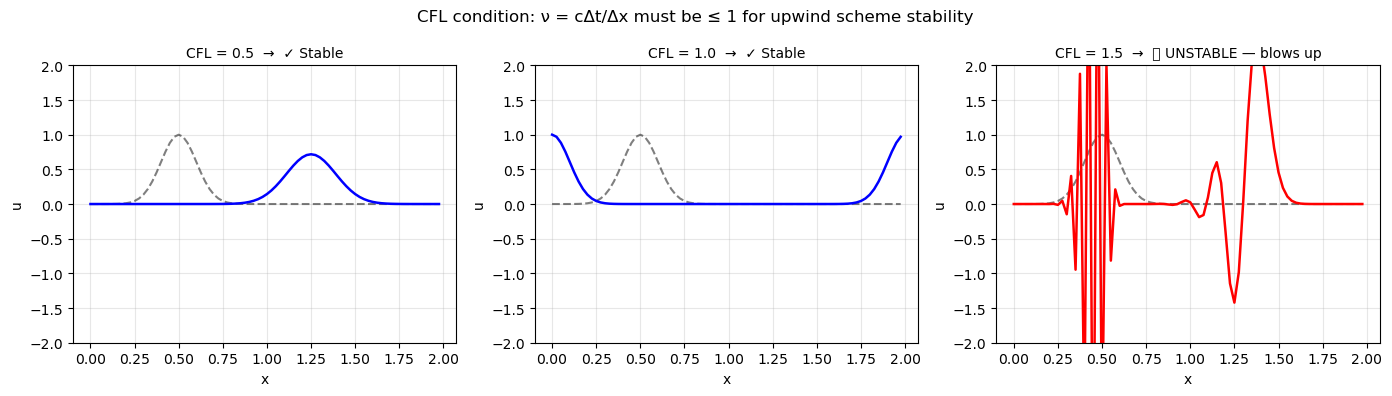

CFL = 0.5: stable, Gaussian moves and stays bounded
CFL = 1.0: stable, exact at CFL=1 for upwind (zero numerical diffusion)
CFL = 1.5: unstable — wave travels 1.5 cells per step,
           jumping past the stencil, error grows exponentially


In [3]:
# ── CFL instability demonstration ───────────────────────────────────────────
# Show what happens when CFL > 1 with the upwind scheme

N   = 80
dx  = 2.0 / N
x   = np.linspace(0, 2, N, endpoint=False)
c   = 1.0
u_init = np.exp(-((x-0.5)**2)/0.02)   # Gaussian blob

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, cfl_val in zip(axes, [0.5, 1.0, 1.5]):
    dt_val = cfl_val * dx / c
    u      = u_init.copy()
    blown  = False

    for step in range(60):
        un = u.copy()
        u[1:]  = un[1:]  - cfl_val * (un[1:]  - un[:-1])
        u[0]   = un[0]   - cfl_val * (un[0]   - un[-1])

        if np.max(np.abs(u)) > 5:
            blown = True
            break

    ax.plot(x, u_init, 'k--', lw=1.5, alpha=0.5, label='Initial')
    ax.plot(x, u, 'r-' if blown else 'b-', lw=1.8)

    status = '💥 UNSTABLE — blows up' if blown else '✓ Stable'
    ax.set_title(f'CFL = {cfl_val}  →  {status}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_ylim(-2, 2); ax.grid(True, alpha=0.3)

plt.suptitle('CFL condition: ν = cΔt/Δx must be ≤ 1 for upwind scheme stability', fontsize=12)
plt.tight_layout()
plt.show()

print('CFL = 0.5: stable, Gaussian moves and stays bounded')
print('CFL = 1.0: stable, exact at CFL=1 for upwind (zero numerical diffusion)')
print('CFL = 1.5: unstable — wave travels 1.5 cells per step,')
print('           jumping past the stencil, error grows exponentially')

## Summary

| Scheme | Stability | Order (space×time) | Error character |
|--------|-----------|-------------------|------------------|
| Upwind (FTBS) | $0 \leq \nu \leq 1$ | 1×1 | Diffusive — smears features |
| FTCS (central) | Unconditionally unstable | 2×1 | Always blows up |
| Lax-Friedrichs | $|\nu| \leq 1$ | 1×1 | Very diffusive |
| Lax-Wendroff | $|\nu| \leq 1$ | 2×2 | Dispersive — oscillates near shocks |

**The CFL condition is the single most important criterion in explicit CFD.**
It says: your time step must be small enough that the wave travels at most one cell. Violate it once and the solution immediately diverges.

**In every solver you write, compute $\Delta t$ as:**
```python
dt = cfl * dx / max_speed    # set cfl=0.5–0.9 for safety
```

---
**Next:** Module 1.7 — 1D Diffusion Equation: implicit vs. explicit time-stepping, and why one scheme needs 100× fewer time steps than the other.

## Exercise

**Predict first, then code.**

1. At CFL = 1, the upwind scheme is exact. Verify this: run the step-function IC with $\nu = 1$ for 50 steps. Does the solution match the exact translation? Why does this happen? (Hint: look at what `u[1:] = un[1:] - 1.0*(un[1:] - un[:-1])` simplifies to when $\nu=1$.)

2. The modified equation for Lax-Wendroff has a dispersive term proportional to $\partial^3 u / \partial x^3$. Given a sine wave $u_0 = \sin(kx)$: does the numerical speed of this wave ($c_{num}$) increase or decrease with wavenumber $k$? Higher-frequency components travel faster or slower than lower-frequency ones?

3. Implement a scheme that switches between upwind and Lax-Wendroff based on the local gradient ratio $r_i = (u_i - u_{i-1})/(u_{i+1} - u_i)$: use Lax-Wendroff where $r > 0$ (smooth region) and upwind where $r \leq 0$ (near extrema). This is the Minmod flux-limited scheme — a preview of Module 3.4.

## FTFS Instability Demo

The following section demonstrates why the Forward Time, Forward Space (FTFS)
scheme is unconditionally unstable for $c > 0$, even at CFL = 0.5.

## FTBS vs FTFS — Upwind vs Downwind Schemes

The two simplest explicit schemes for $\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0$ differ only in **which neighbor** they use for the spatial derivative.

| Scheme | Space stencil | Update equation |
|--------|--------------|-----------------|
| **FTBS** (Backward Space) | looks at $i-1$ | $u_i^{n+1} = u_i^n - \nu(u_i^n - u_{i-1}^n)$ |
| **FTFS** (Forward Space)  | looks at $i+1$ | $u_i^{n+1} = u_i^n - \nu(u_{i+1}^n - u_i^n)$ |

where $\nu = c \Delta t / \Delta x$ is the CFL number.

### The Upwind Principle
Information in an advection equation travels in the direction of $c$:
- $c > 0$: wave moves **right** → upstream is **left** → use **FTBS**
- $c < 0$: wave moves **left** → upstream is **right** → use **FTFS**

Using the wrong direction (looking downstream) causes **exponential blow-up** in just a few steps.

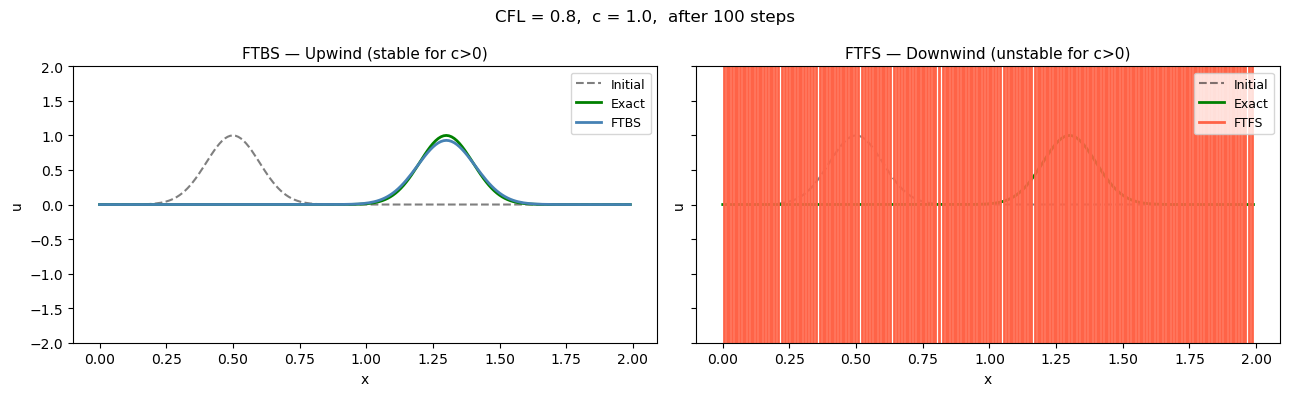

CFL = 0.8
Max |FTBS| = 0.9285  (expect ~1)
Max |FTFS| = 3.83e+34  (blows up!)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Grid & parameters ──────────────────────────────────────────────────────────
L     = 2.0          # domain length
N     = 200          # number of grid points
c     = 1.0          # wave speed (positive = rightward)
cfl   = 0.8          # CFL number (< 1 required for stability)
dx    = L / N
dt    = cfl * dx / c
nt    = 100          # number of time steps

x     = np.linspace(0, L, N, endpoint=False)
x0, sigma = 0.5, 0.1                         # Gaussian pulse parameters

def gaussian(x_arr, center):
    return np.exp(-((x_arr - center) ** 2) / (2 * sigma ** 2))

u0 = gaussian(x, x0)

# ── FTBS: looks LEFT (i-1) — upwind for c > 0 ──────────────────────────────
def ftbs(u):
    u = u.copy()
    for _ in range(nt):
        # np.roll(u, 1) shifts array right by 1, giving u_{i-1}
        u = u - cfl * (u - np.roll(u, 1))
    return u

# ── FTFS: looks RIGHT (i+1) — downwind for c > 0 ───────────────────────────
def ftfs(u):
    u = u.copy()
    for _ in range(nt):
        # np.roll(u, -1) shifts array left by 1, giving u_{i+1}
        u = u - cfl * (np.roll(u, -1) - u)
    return u

# ── Exact solution (periodic wrap) ─────────────────────────────────────────
x_exact = (x - c * nt * dt) % L
u_exact = gaussian(x, x0 + c * nt * dt)    # simple shift (no wrap needed here)

u_ftbs = ftbs(u0)
u_ftfs = ftfs(u0)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

configs = [
    (u_ftbs, "FTBS — Upwind (stable for c>0)",   "steelblue"),
    (u_ftfs, "FTFS — Downwind (unstable for c>0)", "tomato"),
]

for ax, (u_sol, title, color) in zip(axes, configs):
    ax.plot(x, u0,      "k--", lw=1.5, alpha=0.5, label="Initial")
    ax.plot(x, u_exact,  "g-",  lw=2,              label="Exact")
    ax.plot(x, u_sol, color=color, lw=2,            label=title.split("—")[0].strip())
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=9)

plt.suptitle(f"CFL = {cfl},  c = {c},  after {nt} steps", fontsize=12)
plt.tight_layout()
plt.show()

print(f"CFL = {cfl}")
print(f"Max |FTBS| = {np.max(np.abs(u_ftbs)):.4f}  (expect ~1)")
print(f"Max |FTFS| = {np.max(np.abs(u_ftfs)):.2e}  (blows up!)")


## General Upwind Scheme — handles both $c > 0$ and $c < 0$

Instead of two separate functions, we can write one scheme that automatically picks the correct stencil based on the sign of $c$:

$$u_i^{n+1} = u_i^n - \nu \cdot \begin{cases} u_i^n - u_{i-1}^n & \text{if } c > 0 \quad \text{(FTBS)} \\ u_{i+1}^n - u_i^n & \text{if } c < 0 \quad \text{(FTFS)} \end{cases}$$

This can be written compactly using $\max$ and $\min$:

$$u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}\left[ \max(c, 0)(u_i^n - u_{i-1}^n) + \min(c, 0)(u_{i+1}^n - u_i^n) \right]$$

When $c > 0$: the $\min$ term vanishes, leaving FTBS.  
When $c < 0$: the $\max$ term vanishes, leaving FTFS.

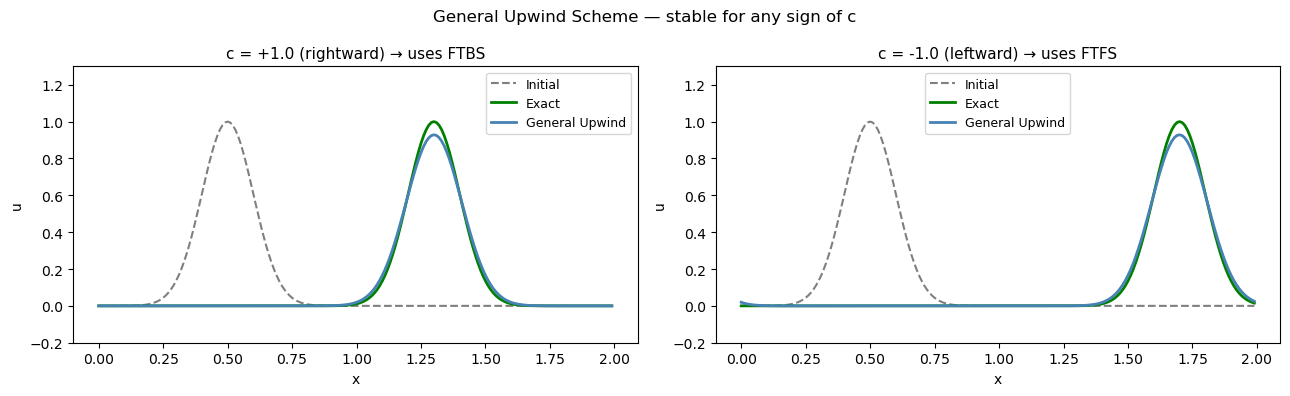

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── General upwind scheme (works for any sign of c) ────────────────────────
def general_upwind(u, c, cfl, nt):
    u = u.copy()
    for _ in range(nt):
        u_left  = np.roll(u,  1)   # u_{i-1}
        u_right = np.roll(u, -1)   # u_{i+1}
        # max(c,0) activates FTBS term; min(c,0) activates FTFS term
        u = u - (dt / dx) * (max(c, 0) * (u - u_left) + min(c, 0) * (u_right - u))
    return u

# ── Setup ───────────────────────────────────────────────────────────────────
L = 2.0;  N = 200;  dx = L / N
x = np.linspace(0, L, N, endpoint=False)
x0, sigma = 0.5, 0.1
cfl = 0.8;  nt = 100

def gaussian(x_arr, center):
    return np.exp(-((x_arr - center) ** 2) / (2 * sigma ** 2))

# ── Run for c = +1 and c = -1 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, c in zip(axes, [1.0, -1.0]):
    dt   = cfl * dx / abs(c)
    u0   = gaussian(x, x0)
    u_num = general_upwind(u0, c, cfl, nt)

    # exact: wave shifts by c * nt * dt, wrapped periodically
    shift = (x0 + c * nt * dt) % L
    u_exact = gaussian(x, shift)

    ax.plot(x, u0,     "k--", lw=1.5, alpha=0.5, label="Initial")
    ax.plot(x, u_exact, "g-",  lw=2,              label="Exact")
    ax.plot(x, u_num,  "steelblue", lw=2,          label="General Upwind")
    direction = "rightward" if c > 0 else "leftward"
    stencil   = "FTBS" if c > 0 else "FTFS"
    ax.set_title(f"c = {c:+.1f} ({direction}) → uses {stencil}", fontsize=11)
    ax.set_xlabel("x");  ax.set_ylabel("u")
    ax.set_ylim(-0.2, 1.3)
    ax.legend(fontsize=9)

plt.suptitle("General Upwind Scheme — stable for any sign of c", fontsize=12)
plt.tight_layout()
plt.show()


## FuncAnimation Visualization Imports

Use the following imports when creating animated visualizations of advection solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2